🔹 STEP 1: Upload Image


Saving group.jpg to group (5).jpg

🔹 STEP 2: Read Image
➡️ OpenCV reads image in BGR format and converts to RGB for display


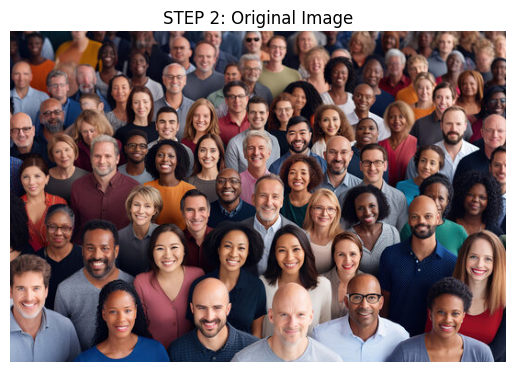


🔹 STEP 3: Convert to Grayscale
➡️ Haar Cascade works on grayscale because it reduces complexity


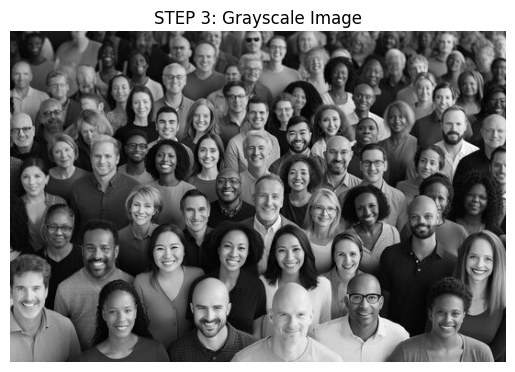


🔹 STEP 4: Haar Cascade Model (Viola-Jones Algorithm)
➡️ Uses Haar-like features (black & white rectangles)
➡️ Detects contrast patterns like eyes, nose bridge


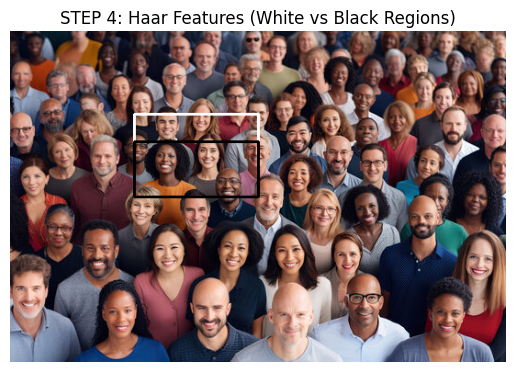


🔹 STEP 5: Sliding Window
➡️ Image is scanned using small windows
➡️ Each window is checked for face features


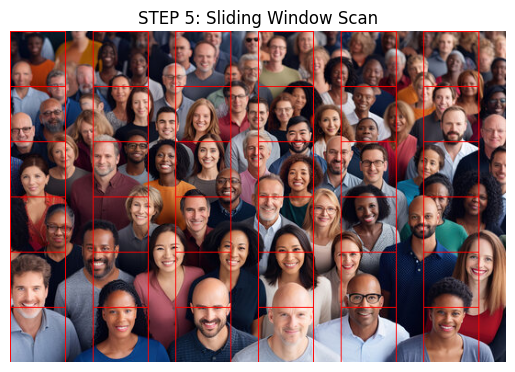


🔹 STEP 6: Feature Extraction
➡️ Extract edges & patterns (similar to Haar features)


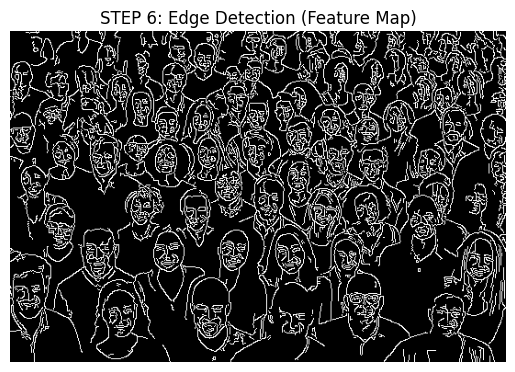


🔹 STEP 7: Cascade Classifier (AdaBoost)
➡️ Multiple stages filter non-face regions
➡️ Early rejection = Faster detection


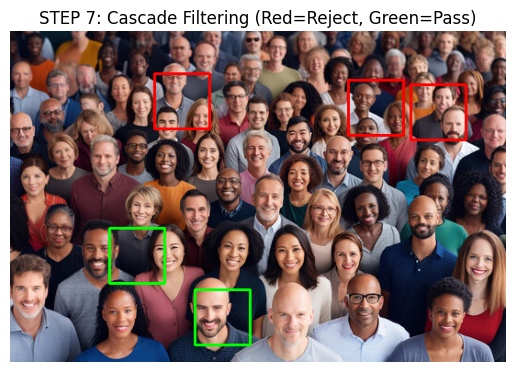


🔹 STEP 8: Detect Faces
➡️ Final detection using trained Haar Cascade model


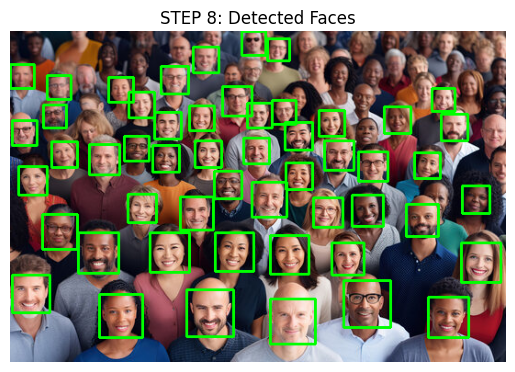


🔹 STEP 9: Final Output


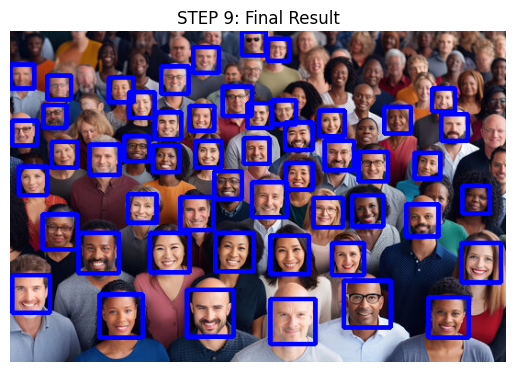


🎯 RESULT:
👉 Number of faces detected: 52

🧠 HOW THE ALGORITHM WORKS (Viola-Jones):

1️⃣ Convert image to grayscale → reduces computation
2️⃣ Use Haar features → detect light/dark patterns
3️⃣ Sliding window → scan entire image
4️⃣ AdaBoost → selects best features
5️⃣ Cascade classifier → reject non-face quickly
6️⃣ Remaining regions → marked as faces

⚡ Viola-Jones = Haar Features + AdaBoost + Cascade Classifier
🎉 Done!


In [6]:
# Install OpenCV (Colab)
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def show(title, img, cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

# -------------------------------
print("🔹 STEP 1: Upload Image")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# -------------------------------
print("\n🔹 STEP 2: Read Image")
print("➡️ OpenCV reads image in BGR format and converts to RGB for display")

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

show("STEP 2: Original Image", img_rgb)

# -------------------------------
print("\n🔹 STEP 3: Convert to Grayscale")
print("➡️ Haar Cascade works on grayscale because it reduces complexity")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show("STEP 3: Grayscale Image", gray, cmap='gray')

# -------------------------------
print("\n🔹 STEP 4: Haar Cascade Model (Viola-Jones Algorithm)")
print("➡️ Uses Haar-like features (black & white rectangles)")
print("➡️ Detects contrast patterns like eyes, nose bridge")

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

model_vis = img_rgb.copy()
h, w = gray.shape

# Example Haar features
cv2.rectangle(model_vis, (w//4, h//4), (w//2, h//3), (255,255,255), 2)
cv2.rectangle(model_vis, (w//4, h//3), (w//2, h//2), (0,0,0), 2)

show("STEP 4: Haar Features (White vs Black Regions)", model_vis)

# -------------------------------
print("\n🔹 STEP 5: Sliding Window")
print("➡️ Image is scanned using small windows")
print("➡️ Each window is checked for face features")

slide = img_rgb.copy()
for i in range(0, w, w//6):
    for j in range(0, h, h//6):
        cv2.rectangle(slide, (i,j), (i+60,j+60), (255,0,0), 1)

show("STEP 5: Sliding Window Scan", slide)

# -------------------------------
print("\n🔹 STEP 6: Feature Extraction")
print("➡️ Extract edges & patterns (similar to Haar features)")

edges = cv2.Canny(gray,100,200)
show("STEP 6: Edge Detection (Feature Map)", edges, cmap='gray')

# -------------------------------
print("\n🔹 STEP 7: Cascade Classifier (AdaBoost)")
print("➡️ Multiple stages filter non-face regions")
print("➡️ Early rejection = Faster detection")

cascade_vis = img_rgb.copy()

for i in range(5):
    x = np.random.randint(0, w-60)
    y = np.random.randint(0, h-60)

    if i < 3:
        color = (255,0,0)  # Rejected
    else:
        color = (0,255,0)  # Passed

    cv2.rectangle(cascade_vis, (x,y), (x+60,y+60), color, 2)

show("STEP 7: Cascade Filtering (Red=Reject, Green=Pass)", cascade_vis)

# -------------------------------
print("\n🔹 STEP 8: Detect Faces")
print("➡️ Final detection using trained Haar Cascade model")

faces = face_cascade.detectMultiScale(gray,1.1,3)

detect = img_rgb.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(detect,(x,y),(x+w,y+h),(0,255,0),2)

show("STEP 8: Detected Faces", detect)

# -------------------------------
print("\n🔹 STEP 9: Final Output")

final = img.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(final,(x,y),(x+w,y+h),(255,0,0),3)

final_rgb = cv2.cvtColor(final, cv2.COLOR_BGR2RGB)
show("STEP 9: Final Result", final_rgb)

# -------------------------------
# ✅ FACE COUNT
num_faces = len(faces)

print("\n🎯 RESULT:")
print(f"👉 Number of faces detected: {num_faces}")

# -------------------------------
# ✅ FINAL ALGORITHM EXPLANATION
print("\n🧠 HOW THE ALGORITHM WORKS (Viola-Jones):\n")

print("1️⃣ Convert image to grayscale → reduces computation")
print("2️⃣ Use Haar features → detect light/dark patterns")
print("3️⃣ Sliding window → scan entire image")
print("4️⃣ AdaBoost → selects best features")
print("5️⃣ Cascade classifier → reject non-face quickly")
print("6️⃣ Remaining regions → marked as faces")

print("\n⚡ Viola-Jones = Haar Features + AdaBoost + Cascade Classifier")
print("🎉 Done!")